# In ML terms
Underfitting = model is too simple / didn't learn enough → performs badly on BOTH training data and test data
Overfitting = model is too complex / memorized training data too closely → performs GREAT on training data, but BADLY on test data (new data)
Good fit = model learned the general pattern → performs well on both

# PROBLEM 1 — Basic Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
temp=np.array([15, 18, 20, 22, 25, 28, 30, 32, 35, 38])
ice_cream_sales= np.array([200, 230, 260, 300, 340, 380, 410, 450, 480, 520])

In [3]:
x=temp.reshape(-1,1)
y=ice_cream_sales

<function matplotlib.pyplot.show(close=None, block=None)>

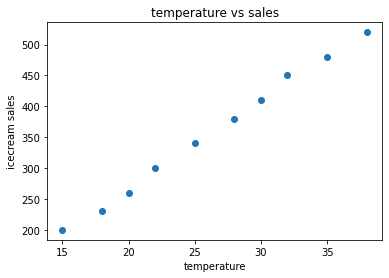

In [4]:
plt.scatter(x,y)
plt.xlabel("temperature")
plt.ylabel("icecream sales")
plt.title("temperature vs sales")
plt.show

In [5]:
model=LinearRegression()
model.fit(x,y)

print("slope",model.coef_[0]) #how much it changes;
print("Intercept:", model.intercept_) #where it starts.

slope 14.377533294730748
Intercept: -21.12912565141869


model.coef_[0] = 7.2 → for every 1 extra study hour, marks increase by about 7.2.
model.intercept_ = 28 → when study hours are 0, the model starts with 28 marks.

So the prediction is:

Marks = 7.2 × Study_Hours + 28

For 5 hours:

7.2 × 5 + 28 = 64

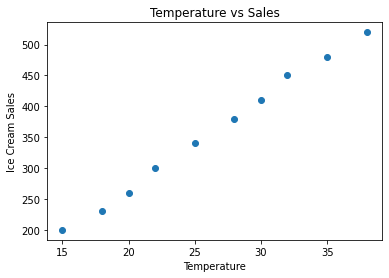

Slope: 14.377533294730748
Intercept: -21.12912565141869
Predicted sales at 33°C: 453.329473074696
Test Score: 0.9967147884711537
Actual: [480 230]
Predicted: [482.24899598 239.87951807]
Coefficients (sqft, bedrooms, age): [[ 0.04898573  3.75532181 -0.22289006]]
Predicted price: [[85.90095167]]
Train Score: 0.9987791699893839
Test Score: 0.9309987834471796
Linear coef_: [[ 0.0446798   3.57799672 -0.77011494]]
Ridge coef_: [ 0.04998089  1.16494286 -0.73921985]
Lasso coef_: [ 0.05285834  0.         -0.66261042]


In [1]:
# ============================================
# PROBLEM 1 — Basic Linear Regression
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

temperature = np.array([15, 18, 20, 22, 25, 28, 30, 32, 35, 38])
ice_cream_sales = np.array([200, 230, 260, 300, 340, 380, 410, 450, 480, 520])

X = temperature.reshape(-1, 1)
Y = ice_cream_sales

plt.scatter(X, Y)
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Temperature vs Sales")
plt.show()

model = LinearRegression()
model.fit(X, Y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

predicted = model.predict([[33]])
print("Predicted sales at 33°C:", predicted[0])


# ============================================
# PROBLEM 2 — Train/Test Split + Score
# ============================================
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(x_train, y_train)

y_pred = model2.predict(x_test)

print("Test Score:", model2.score(x_test, y_test))
print("Actual:", y_test)
print("Predicted:", y_pred)


# ============================================
# PROBLEM 3 — Multiple Linear Regression
# ============================================
import pandas as pd

data = {
    'sqft': [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500],
    'bedrooms': [1, 2, 2, 3, 3, 4, 4, 5],
    'age': [10, 8, 15, 5, 3, 12, 2, 1],
    'price': [40, 55, 60, 80, 95, 100, 120, 140]
}
df = pd.DataFrame(data)

X3 = df.iloc[:, 0:3].values
Y3 = df.iloc[:, 3:4].values

x_train3, x_test3, y_train3, y_test3 = train_test_split(X3, Y3, test_size=0.25, random_state=42)

model3 = LinearRegression()
model3.fit(x_train3, y_train3)

print("Coefficients (sqft, bedrooms, age):", model3.coef_)

new_house = [[1600, 3, 6]]
print("Predicted price:", model3.predict(new_house))


# ============================================
# PROBLEM 4 — Overfitting Check
# ============================================
train_score = model3.score(x_train3, y_train3)
test_score = model3.score(x_test3, y_test3)

print("Train Score:", train_score)
print("Test Score:", test_score)


# ============================================
# PROBLEM 5 — Ridge vs Lasso
# ============================================
from sklearn.linear_model import Ridge, Lasso

linear_model = LinearRegression()
linear_model.fit(X3, Y3)

ridge_model = Ridge(alpha=1)
ridge_model.fit(X3, Y3)

lasso_model = Lasso(alpha=1)
lasso_model.fit(X3, Y3)

print("Linear coef_:", linear_model.coef_)
print("Ridge coef_:", ridge_model.coef_)
print("Lasso coef_:", lasso_model.coef_)